In [1]:
import kagglehub
import matplotlib.pyplot as plt
from kagglehub import KaggleDatasetAdapter
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, KFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.pipeline import Pipeline


In [2]:
file_path = "Heart_disease_cleveland_new.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "ritwikb3/heart-disease-cleveland",
  file_path
)

print("First 5 records:", df.head())

/tmp/ipykernel_225489/2072479301.py:4: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


First 5 records:    age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   0       145   233    1        2      150      0      2.3      2   
1   67    1   3       160   286    0        2      108      1      1.5      1   
2   67    1   3       120   229    0        2      129      1      2.6      1   
3   37    1   2       130   250    0        0      187      0      3.5      2   
4   41    0   1       130   204    0        2      172      0      1.4      0   

   ca  thal  target  
0   0     2       0  
1   3     1       1  
2   2     3       1  
3   0     1       0  
4   0     1       0  


In [3]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.438944,0.679868,2.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,0.600660,0.663366,1.831683,0.458746
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.934375,0.956705,0.499120
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,48.000000,0.000000,2.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,56.000000,1.000000,2.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,1.000000,0.000000
75%,61.000000,1.000000,3.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,1.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,3.000000,3.000000,1.000000


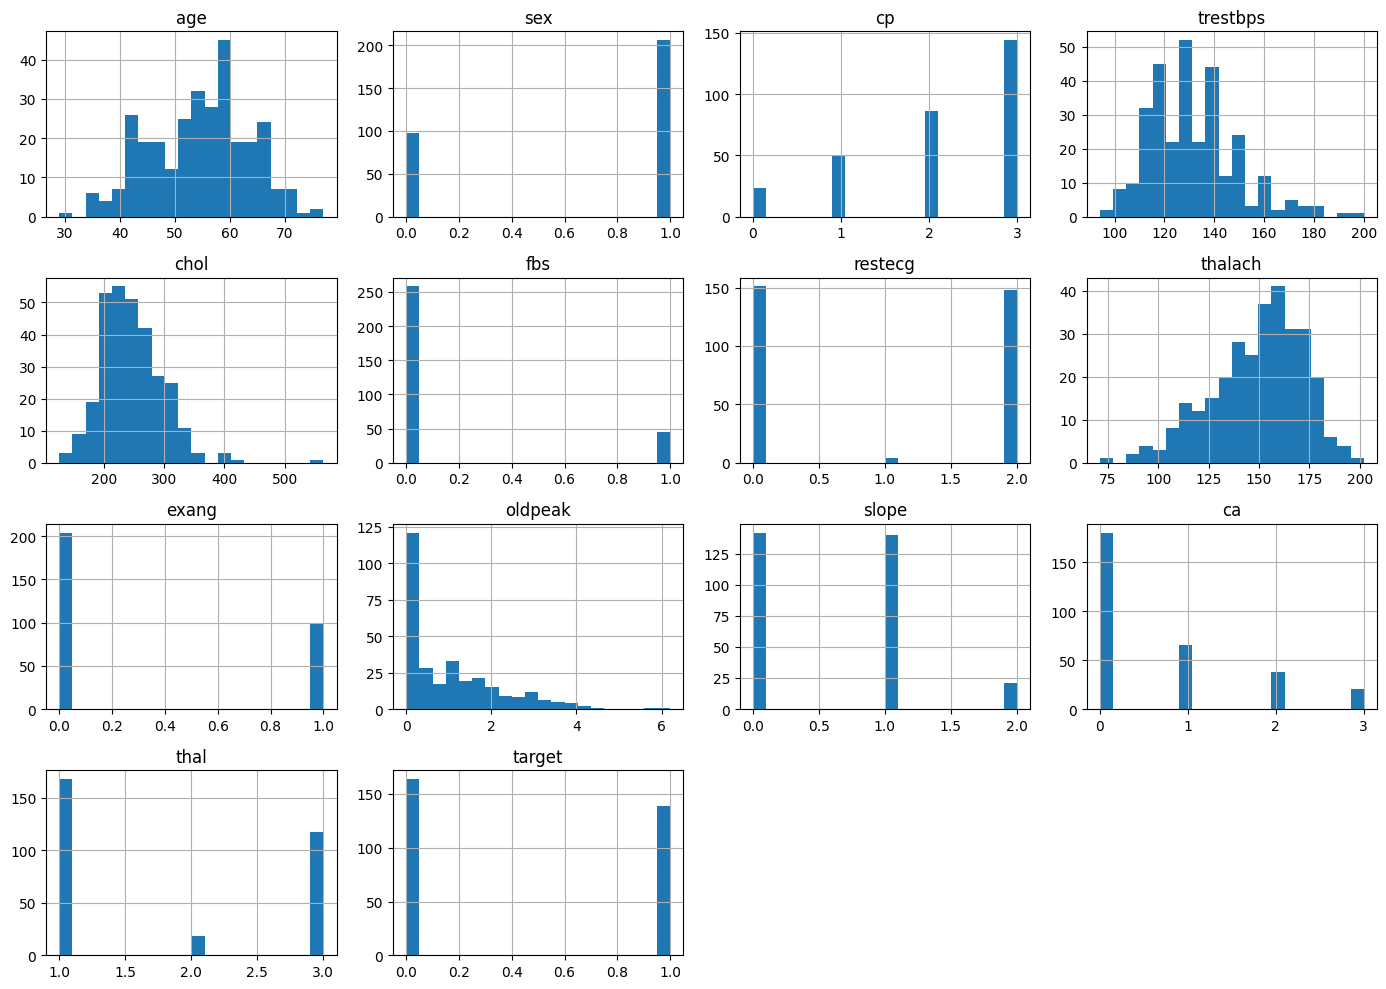

In [4]:
df.hist(figsize=(14, 10), bins=20)
plt.tight_layout()
plt.show()

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


## Opis kolumn

| Kolumna | Opis | Typ |
|---------|------|-----|
| age | Wiek pacjenta (lata) | Numeryczna |
| sex | Płeć (1 = mężczyzna, 0 = kobieta) | Nominalna |
| cp | Typ bólu klatki piersiowej (0 = typowa dławica, 1 = atypowa dławica, 2 = ból nie-dławicowy, 3 = bezobjawowy) | Nominalna |
| trestbps | Ciśnienie krwi w spoczynku (mm Hg) | Numeryczna |
| chol | Cholesterol w surowicy (mg/dl) | Numeryczna |
| fbs | Cukier we krwi na czczo > 120 mg/dl (1 = tak, 0 = nie) | Nominalna |
| restecg | Wynik EKG w spoczynku (0 = norma, 1 = nieprawidłowości ST-T, 2 = przerost lewej komory) | Nominalna |
| thalach | Maksymalne osiągnięte tętno | Numeryczna |
| exang | Dławica wysiłkowa (1 = tak, 0 = nie) | Nominalna |
| oldpeak | Obniżenie ST wywołane wysiłkiem względem spoczynku | Numeryczna |
| slope | Nachylenie segmentu ST przy wysiłku (0 = rosnący, 1 = płaski, 2 = malejący) | Nominalna |
| ca | Liczba głównych naczyń (0–3) | Nominalna |
| thal | Talasemia (0 = brak danych, 1 = norma, 2 = defekt stały, 3 = defekt odwracalny) | Nominalna |
| target | Zmienna docelowa (1 = choroba serca, 0 = zdrowy) | Nominalna |

In [6]:
print(df['target'].value_counts())

X = df.drop(columns=['target'])
y = df['target']

target
0    164
1    139
Name: count, dtype: int64


In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=50, stratify=y)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train target: {y_train.value_counts().to_dict()}")
print(f"Test target: {y_test.value_counts().to_dict()}")


Train: (242, 13), Test: (61, 13)
Train target: {0: 131, 1: 111}
Test target: {0: 33, 1: 28}


In [8]:
model = LogisticRegression()
model.fit(X_train, y_train)

/home/blazejdelag/ml_lab/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [9]:
y_pred = model.predict(X_test)

Bazowy model


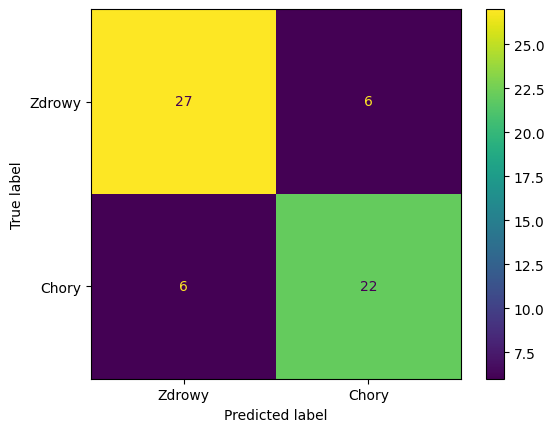

Accuracy 0.8033
Precision 0.7857
Recall 0.7857
F1-score 0.7857



In [10]:
def evaluate(y_test, y_pred, label=""):
    print(label)
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['Zdrowy', 'Chory'])
    plt.show()
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    print(f"Accuracy {acc:.4f}")
    print(f"Precision {prec:.4f}")
    print(f"Recall {rec:.4f}")
    print(f"F1-score {f1:.4f}")
    print()

evaluate(y_test, y_pred, "Bazowy model")

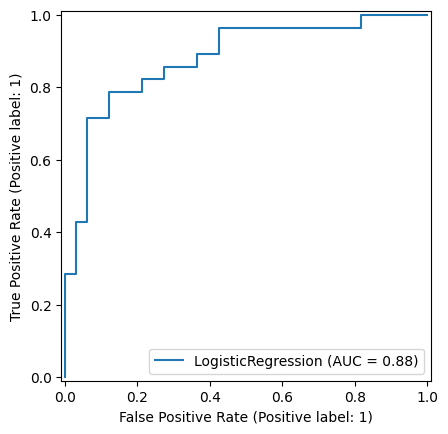

In [11]:
roc_disp = RocCurveDisplay.from_estimator(model, X_test, y_test)

## Interpretacja metryk klasyfikacji

Model bazowy osiągnął accuracy 80.3%, co oznacza, że poprawnie klasyfikuje około 4 na 5 pacjentów.

**Macierz pomyłek:**
- TN = 27 — zdrowi poprawnie rozpoznani jako zdrowi
- TP = 22 — chorzy poprawnie rozpoznani jako chorzy
- FP = 6 — zdrowi błędnie sklasyfikowani jako chorzy - fałszywy alarm
- FN = 6 — chorzy błędnie sklasyfikowani jako zdrowi - przeoczenie

**Wybrane metryki — precyzja i czułość:**
- Precision = 0.786 — spośród pacjentów, których model uznał za chorych, 78.6% faktycznie jest chorych.
- Recall = 0.786 — spośród wszystkich faktycznie chorych, model wykrył 78.6%.

W kontekście diagnostyki chorób serca czułość jest ważniejsza niż precyzja — przeoczenie chorego pacjenta (FN) jest groźniejsze niż fałszywy alarm (FP). Fałszywy alarm oznacza dodatkowe badania, ale przeoczenie choroby może zagrażać życiu. W naszym modelu FN = 6, co oznacza, że 6 chorych pacjentów nie zostałoby skierowanych na leczenie.

**Krzywa ROC:**
AUC = 0.88, co oznacza dobrą zdolność modelu do rozróżniania chorych od zdrowych. Krzywa wyraźnie odbiega od przekątnej (model losowy = 0.5), co potwierdza, że model ma wartość predykcyjną.

In [12]:
scaler = MinMaxScaler()

scaler.fit(X_train)
X_train_norm = scaler.transform(X_train)
X_test_norm = scaler.transform(X_test)

scaler = StandardScaler()

scaler.fit(X_train)
X_train_std = scaler.transform(X_train)
X_test_std = scaler.transform(X_test)

Normalizacja


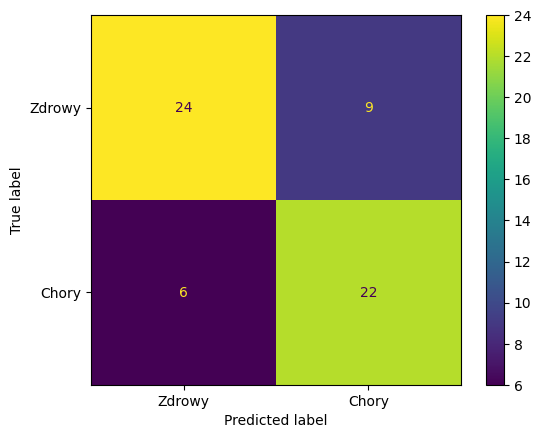

Accuracy 0.7541
Precision 0.7097
Recall 0.7857
F1-score 0.7458

Standaryzacja


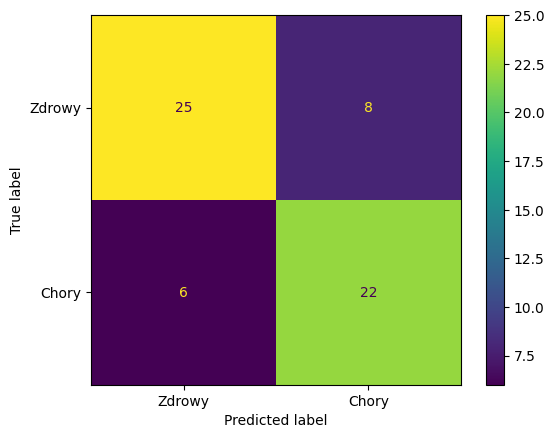

Accuracy 0.7705
Precision 0.7333
Recall 0.7857
F1-score 0.7586



In [13]:
model_norm = LogisticRegression()
model_norm.fit(X_train_norm, y_train)
y_pred_norm = model_norm.predict(X_test_norm)
evaluate(y_test, y_pred_norm, "Normalizacja")

model_std =  LogisticRegression()
model_std.fit(X_train_std, y_train)
y_pred_std = model_std.predict(X_test_std)
evaluate(y_test, y_pred_std, "Standaryzacja")

## Wpływ standaryzacji i normalizacji

| Metryka | Bez skalowania | Normalizacja | Standaryzacja |
|---------|---------------|--------------|---------------|
| Accuracy | 0.803 | 0.754 | 0.770 |
| Precision | 0.786 | 0.710 | 0.733 |
| Recall | 0.786 | 0.786 | 0.786 |
| F1-score | 0.786 | 0.746 | 0.759 |

Czułość (recall) pozostała identyczna we wszystkich trzech przypadkach — model wykrywa tę samą liczbę chorych (TP=22, FN=6). Różnice widać w precyzji — po skalowaniu model generuje więcej fałszywych alarmów.

W tym przypadku skalowanie nie poprawiło wyników. Może to wynikać z tego, że model bazowy (bez skalowania) miał domyślnie włączoną regularyzację, która poradziła sobie z różnymi skalami cech. Natomiast ogólnie o skalowaniu trzeba pamiętać, szczególnie gdy porównujemy wpływ hiperparametrów — dlatego w kolejnych eksperymentach używamy danych standaryzowanych.

C=0.001


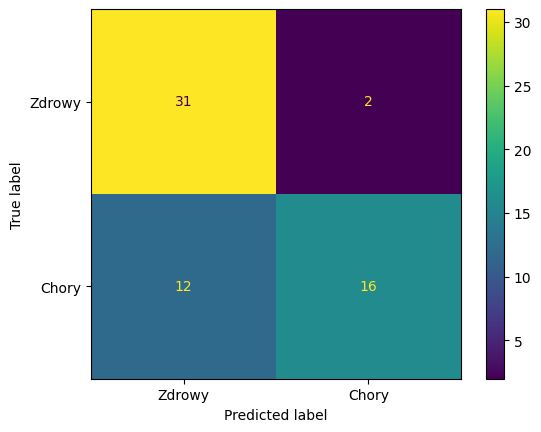

Accuracy 0.7705
Precision 0.8889
Recall 0.5714
F1-score 0.6957

C=0.01


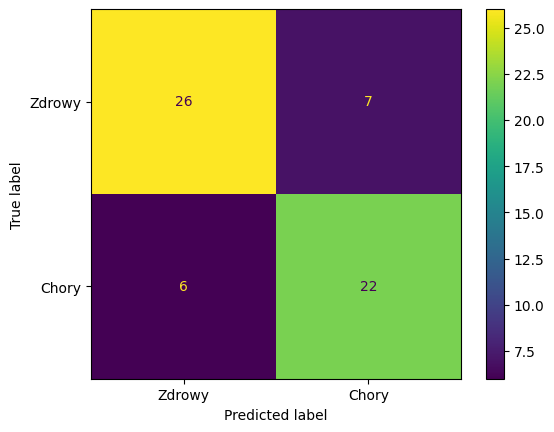

Accuracy 0.7869
Precision 0.7586
Recall 0.7857
F1-score 0.7719

C=0.1


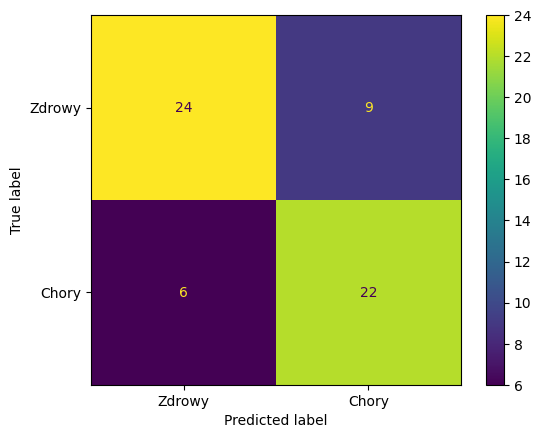

Accuracy 0.7541
Precision 0.7097
Recall 0.7857
F1-score 0.7458

C=1


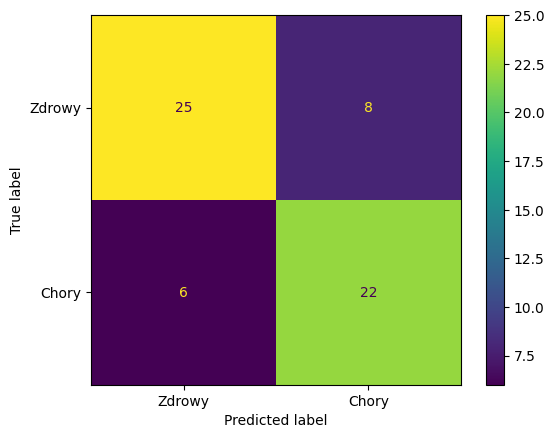

Accuracy 0.7705
Precision 0.7333
Recall 0.7857
F1-score 0.7586

C=10


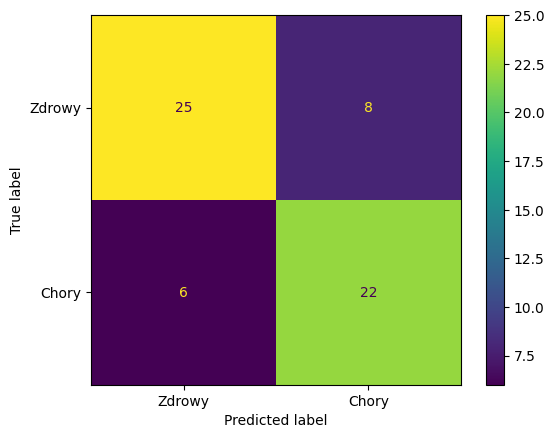

Accuracy 0.7705
Precision 0.7333
Recall 0.7857
F1-score 0.7586

C=100


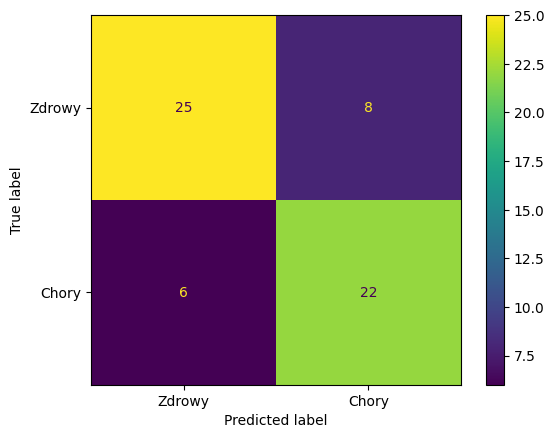

Accuracy 0.7705
Precision 0.7333
Recall 0.7857
F1-score 0.7586



In [14]:
for c in [0.001, 0.01, 0.1, 1, 10, 100]:
    model =  LogisticRegression(C=c, max_iter=1000)
    model.fit(X_train_std, y_train)
    y_pred_c = model.predict(X_test_std)
    evaluate(y_test, y_pred_c, f"C={c}")

l1_ratio=0


/home/blazejdelag/ml_lab/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


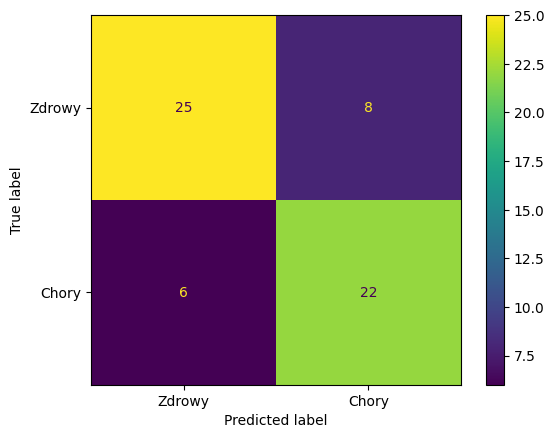

Accuracy 0.7705
Precision 0.7333
Recall 0.7857
F1-score 0.7586

l1_ratio=0.25


/home/blazejdelag/ml_lab/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


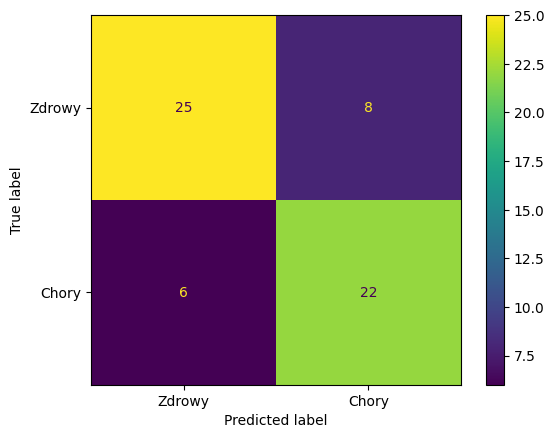

Accuracy 0.7705
Precision 0.7333
Recall 0.7857
F1-score 0.7586

l1_ratio=0.5


/home/blazejdelag/ml_lab/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


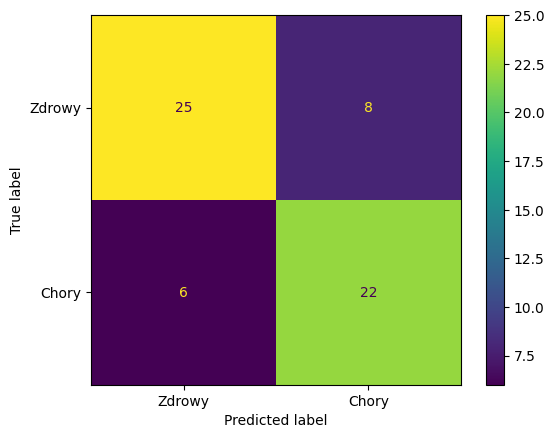

Accuracy 0.7705
Precision 0.7333
Recall 0.7857
F1-score 0.7586

l1_ratio=0.75


/home/blazejdelag/ml_lab/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


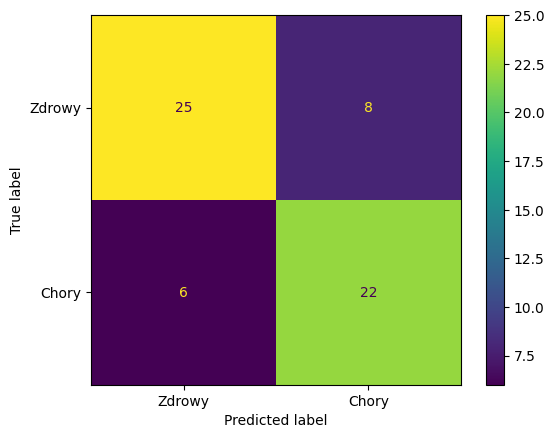

Accuracy 0.7705
Precision 0.7333
Recall 0.7857
F1-score 0.7586

l1_ratio=1


/home/blazejdelag/ml_lab/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


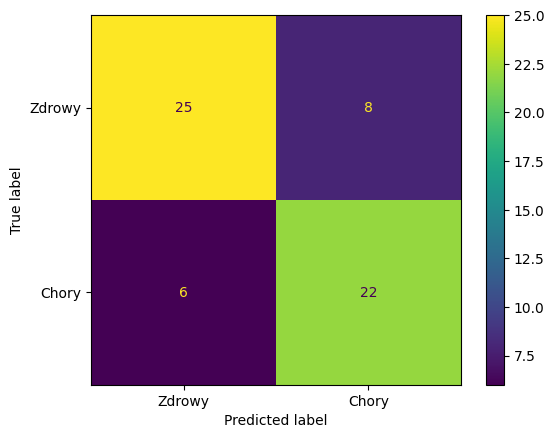

Accuracy 0.7705
Precision 0.7333
Recall 0.7857
F1-score 0.7586



In [15]:
for l_ratio in [0, 0.25, 0.5, 0.75, 1]:
    model =  LogisticRegression(penalty='elasticnet', solver='saga', l1_ratio=l_ratio, max_iter=1000)
    model.fit(X_train_std, y_train)
    y_pred_ratio = model.predict(X_test_std)
    evaluate(y_test, y_pred_ratio, f"l1_ratio={l_ratio}")

## Wpływ hiperparametrów

### Parametr C (siła regularyzacji)

C kontroluje siłę regularyzacji — im mniejsze C, tym silniejsza regularyzacja (model prostszy, mniej podatny na overfitting).

| C | Accuracy | Precision | Recall | F1-score |
|---|----------|-----------|--------|----------|
| 0.001 | 0.770 | 0.889 | 0.571 | 0.696 |
| 0.01 | 0.787 | 0.759 | 0.786 | 0.772 |
| 0.1 | 0.754 | 0.710 | 0.786 | 0.746 |
| 1 | 0.770 | 0.733 | 0.786 | 0.759 |
| 10 | 0.770 | 0.733 | 0.786 | 0.759 |
| 100 | 0.770 | 0.733 | 0.786 | 0.759 |

Przy bardzo silnej regularyzacji (C=0.001) model ma najwyższą precyzję (0.889), ale najniższą czułość (0.571) — jest ostrożny w diagnozowaniu choroby, przez co przeocza aż 12 chorych pacjentów. Dla C=0.01 model osiąga najlepszy kompromis (najwyższe F1 = 0.772). Od C=1 wzwyż wyniki się stabilizują — dalsze osłabianie regularyzacji nie zmienia modelu.

### Parametr l1_ratio

l1_ratio kontroluje proporcję między regularyzacją L1 (zerowanie wag) a L2 (zmniejszanie wag). 0 = czyste L2, 1 = czyste L1.

Zmiana l1_ratio nie wpłynęła na wyniki — wszystkie konfiguracje dały identyczne metryki. Oznacza to, że na tym zbiorze danych typ regularyzacji nie ma istotnego znaczenia — żadna cecha nie jest na tyle redundantna, żeby L1 ją wyzerowała i poprawiła model.

In [16]:
pipe = Pipeline([('scaler', StandardScaler()), ('model', LogisticRegression(max_iter=1000))])
for cur_cv in [2, 5, 10]:   
    kf = KFold(n_splits=cur_cv) 
    score = cross_val_score(pipe, X, y, cv=kf, scoring='accuracy')
    skf = StratifiedKFold(n_splits=cur_cv)
    score_strat = cross_val_score(pipe, X, y, cv=skf, scoring='accuracy')
    print(f"cv={cur_cv}:")
    print(f"  Zwykły:        mean={score.mean():.4f}, std={score.std():.4f}")
    print(f"  Stratified:    mean={score_strat.mean():.4f}, std={score_strat.std():.4f}")
    print()

cv=2:
  Zwykły:        mean=0.8382, std=0.0236
  Stratified:    mean=0.8283, std=0.0270

cv=5:
  Zwykły:        mean=0.8250, std=0.0633
  Stratified:    mean=0.8249, std=0.0391

cv=10:
  Zwykły:        mean=0.8217, std=0.1029
  Stratified:    mean=0.8216, std=0.0846



## Walidacja krzyżowa

| k-fold | Zwykły (mean) | Zwykły (std) | Stratified (mean) | Stratified (std) |
|--------|--------------|-------------|-------------------|-----------------|
| 2 | 0.838 | 0.024 | 0.828 | 0.027 |
| 5 | 0.825 | 0.063 | 0.825 | 0.039 |
| 10 | 0.822 | 0.103 | 0.822 | 0.085 |

**Średnie wyniki** są zbliżone niezależnie od liczby foldów (~82-84%). Więcej foldów oznacza większy zbiór treningowy w każdej rundzie, ale mniejszy zbiór testowy, co powoduje większą zmienność wyników.

**Zmienność (std)** rośnie wyraźnie z liczbą foldów — od 0.024 przy 2-fold do 0.103 przy 10-fold. To dlatego, że przy 10-fold testujemy na ~30 próbkach, więc wynik każdego folda jest bardziej zależny od tego, które próbki akurat wpadły do testu.

**Stratyfikacja** nie zmienia średnich wyników, ale wyraźnie zmniejsza zmienność — szczególnie widoczne przy 5-fold (0.063-> 0.039) i 10-fold (0.103 -> 0.085). Stratyfikacja gwarantuje, że w każdym foldzie proporcja chorych do zdrowych jest taka sama jak w całym zbiorze, co daje bardziej stabilne wyniki.